# 02 · Logistic-regression baseline (Session 2)

Goal: establish the **floor** every later model must beat, using only
information known at loan **application**, evaluated **out-of-time**.

Decisions locked in Session 2 (see README for the reasoning):
- **Label:** `Charged Off` / `Default` → 1, `Fully Paid` → 0; everything
  in-progress dropped so every row has a conclusive outcome.
- **Maturity cutoff:** drop loans issued after **Dec 2016**. The 2017 vintages
  are ~59% still `Current` (too censored to trust); 2016 is ~31% censored, kept
  for its volume with the bias documented.
- **Out-of-time split:** train on loans issued **≤ 2015-12**, test on **all of
  2016**. Mirrors production (predict the future from the past) and exposes
  concept drift a random split would hide.
- **grade / sub_grade / int_rate** are held out of training (KFCDT) for a
  later with/without-LC comparison.
- **No class reweighting** — we want calibrated probabilities for the
  expected-loss decision in a later session.

All preprocessing is fit on the **training split only** (via a scikit-learn
`Pipeline`) so no test-set statistics leak into the model.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import data_prep as dp
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)

## Step A — Load & define the label

In [2]:
df = dp.load_frame()
df = dp.build_label(df)
print(f"Finished loans: {len(df):,}")
print(f"Base default rate: {df['default'].mean():.3%}")
df['loan_status'].value_counts()

Finished loans: 1,345,350
Base default rate: 19.965%


loan_status
Fully Paid     1076751
Charged Off     268559
Default             40
Name: count, dtype: int64

## Step B — Parse types & apply the maturity cutoff

We parse the messy strings (`term`, `emp_length`), turn the two date columns
into a single application-time feature `credit_age_months`
(issue date − earliest credit line), then drop loans issued after Feb 2017.

In [3]:
df = dp.parse_types(df)
before = len(df)
df = dp.apply_maturity_cutoff(df)
print(f"After maturity cutoff (<= {dp.MATURITY_CUTOFF}): {len(df):,} "
      f"({before-len(df):,} dropped)")
print(f"Default rate after cutoff: {df['default'].mean():.3%}")

After maturity cutoff (<= 2016-12): 1,119,711 (225,639 dropped)
Default rate after cutoff: 19.698%


## Step C — Out-of-time split

In [4]:
train, test = dp.time_split(df)
feats = dp.model_feature_list(df)
nums, cats = dp.split_feature_types(df, feats)

# Drop features that are entirely empty in TRAIN (later-vintage-only fields
# such as sec_app_*, which didn't exist in LC's data before ~2017).
empty_in_train = [c for c in nums if train[c].notna().sum() == 0]
if empty_in_train:
    print(f"Dropping {len(empty_in_train)} features empty in train: {empty_in_train}")
    nums = [c for c in nums if c not in empty_in_train]
    feats = [c for c in feats if c not in empty_in_train]

print(f"\ntrain: {len(train):,} rows ({train.issue_dt.min():%Y-%m}..{train.issue_dt.max():%Y-%m}), "
      f"default {train['default'].mean():.3%}")
print(f"test : {len(test):,} rows ({test.issue_dt.min():%Y-%m}..{test.issue_dt.max():%Y-%m}), "
      f"default {test['default'].mean():.3%}")
print(f"features: {len(feats)} ({len(nums)} numeric, {len(cats)} categorical)")

X_train, y_train = train[feats], train['default']
X_test, y_test = test[feats], test['default']

Dropping 12 features empty in train: ['revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_major_derog', 'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_open_act_il', 'sec_app_revol_util']

train: 826,606 rows (2007-06..2015-12), default 18.425%
test : 293,105 rows (2016-01..2016-12), default 23.286%
features: 82 (75 numeric, 7 categorical)


**Note the default-rate jump** (train ~18.4% → test ~23.3%). Part is real
drift, part is the censoring bias in the recent test vintages we accepted with
the lenient cutoff. A random split would have averaged this away and hidden it.

## Step D — Preprocessing pipeline (fit on train only)

- **Numeric:** median-impute (+ a *was-missing* indicator, since a missing
  `mths_since_last_delinq` means "never delinquent" — real signal) → standardize.
- **Categorical:** constant-impute → one-hot with **drop-first** (the n−1
  reference coding that avoids the dummy-variable trap).

In [5]:
pre = dp.build_preprocessor(nums, cats)
pre  # inspect the ColumnTransformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Step E — Fit the L2 logistic baseline & evaluate out-of-time

Deliberately untuned — this is the floor, not the finished model.

In [6]:
clf = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
pipe = Pipeline([('pre', pre), ('clf', clf)])
pipe.fit(X_train, y_train)

p_test = pipe.predict_proba(X_test)[:, 1]
p_train = pipe.predict_proba(X_train)[:, 1]

fpr, tpr, _ = roc_curve(y_test, p_test)
auc = roc_auc_score(y_test, p_test)
ks = float(np.max(tpr - fpr))
gini = 2*auc - 1

print(f"ROC-AUC : {auc:.4f}   (train {roc_auc_score(y_train, p_train):.4f})")
print(f"Gini    : {gini:.4f}")
print(f"KS      : {ks:.4f}")

/Users/graysonschultz/projects/Lending_Club_Credit_Risk_Model/venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


ROC-AUC : 0.7092   (train 0.7158)
Gini    : 0.4185
KS      : 0.3012


### Reading the finance metrics
- **ROC-AUC** — probability the model ranks a random defaulter above a random
  payer. 0.5 = coin flip.
- **Gini = 2·AUC − 1** — the same information rescaled to 0–1; the standard
  scorecard summary.
- **KS** — the largest gap between the cumulative good and bad distributions;
  how well a single cutoff separates the two populations.

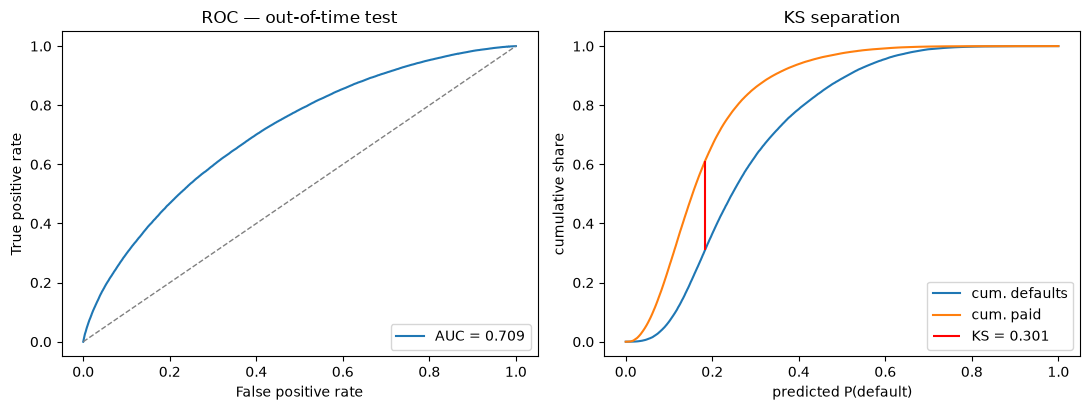

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# ROC curve
ax[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate',
          title='ROC — out-of-time test')
ax[0].legend(loc='lower right')

# KS: cumulative distributions of the score by class
order = np.argsort(p_test)
s = p_test[order]; y = np.asarray(y_test)[order]
cum_bad = np.cumsum(y) / y.sum()
cum_good = np.cumsum(1 - y) / (len(y) - y.sum())
ax[1].plot(s, cum_bad, label='cum. defaults')
ax[1].plot(s, cum_good, label='cum. paid')
k = np.argmax(np.abs(cum_bad - cum_good))
ax[1].vlines(s[k], cum_good[k], cum_bad[k], color='red', label=f'KS = {ks:.3f}')
ax[1].set(xlabel='predicted P(default)', ylabel='cumulative share',
          title='KS separation')
ax[1].legend(loc='lower right')
fig.tight_layout()
fig.savefig(REPORTS / 'baseline_roc_ks.png', dpi=120, bbox_inches='tight')
plt.show()

## Which features drive the score?

Coefficients from the standardized logistic fit. Numeric coefficients are
comparable to each other (same scale); one-hot categories are 0/1, so compare
those within a variable, not against the numerics.

In [8]:
import pandas as pd
names = pipe.named_steps['pre'].get_feature_names_out()
coef = pipe.named_steps['clf'].coef_[0]
coefs = (pd.DataFrame({'feature': names, 'coef': coef})
         .assign(abs=lambda d: d.coef.abs())
         .sort_values('abs', ascending=False))
print("Top 15 by |coefficient| (positive => higher default risk):")
coefs.head(15)[['feature', 'coef']].reset_index(drop=True)

Top 15 by |coefficient| (positive => higher default risk):


,feature,coef
0,num__installment,0.649090
1,num__term,0.618504
2,num__funded_amnt_inv,-0.549737
3,cat__purpose_small_business,0.522157
4,cat__home_ownership_MORTGAGE,-0.505959
5,cat__home_ownership_OWN,-0.392136
6,cat__purpose_wedding,-0.361402
7,cat__home_ownership_RENT,-0.277285
8,cat__purpose_credit_card,-0.264828
9,cat__purpose_moving,0.224666


## Takeaways & next steps

- **Baseline to beat: AUC ≈ 0.71 / Gini ≈ 0.42 / KS ≈ 0.30**, out-of-time.
- Small train↔test AUC gap → the model generalizes across the time boundary;
  it isn't overfitting.
- The out-of-time design already earned its keep: it exposed (a) the
  train/test default-rate drift and (b) 12 secondary-applicant features that
  are unusable because they postdate the training era.

**Session 3:** RandomForest → XGBoost/LightGBM bake-off (same split, same
metrics), then the with/without-LC-`grade` comparison, then a calibration
curve and the expected-loss threshold.